Agent的基本用法1：模型的传入方式
在 LangChain 1.2 中，
create_agent 是构建智能体的核心方式，底层基于
LangGraph 实现。

create_agent 完整参数：


In [ ]:
from langchain.agents import create_agent

agent = create_agent(
    model: str | BaseChatModel,  # 必需：聊天模型
tools: List[BaseTool],  # 必需：工具列表
*,
system_prompt: str = "",  # 系统提示词
middleware: Seguence[AgentMiddleware[StateT_co, ContextT]] = ()  # 中间件
interrupt_before: List[str] = None,  # 在某些工具前暂停（人机协作）
interrupt_after: List[str] = None,  # 在某些工具后暂停
debug: bool = False  # 调试模式
name: str 丨 None = None,  # 设置模型名称
)

Agent中模型的传入方式：
本节我们只关注模型的传入。
模型是 Agent 的“大脑”，负责决策和推理。根据模型传入agent方式的不同，分为两种方式。
2.1 传入模型字符串

In [2]:
from langchain.agents import create_agent
from dotenv import load_dotenv

load_dotenv(override=True)
agent = create_agent("deepseek-v4-flash")
print(type(agent))



<class 'langgraph.graph.state.CompiledStateGraph'>


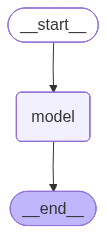

In [9]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

由上可知，agent本质上是LangGraph的CompiledStateGraph实例，底层实现是一个图结构。
通过上述代码最后一行可以看到agent的图结构。

2.2 传入模型对象

In [3]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from dotenv import load_dotenv
import os

load_dotenv(override=True)
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = "https://api.deepseek.com"
model = init_chat_model(
    model="deepseek-v4-flash",
    model_provider="deepseek",
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL,
    extra_body={"thinking": {"type": "disabled"}}  #关闭思考模式
)
agent = create_agent(model)
print(type(agent))


<class 'langgraph.graph.state.CompiledStateGraph'>


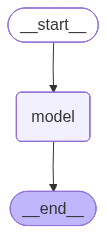

In [12]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

Agent的基本用法2：如何调用Agent
agent.invoke()是Agent 最基本的同步调用方法，它会阻塞程序执行直到返回最终结果。具体的：
输入：传入的参数为字典类型，字典内通过messages字段传递消息列表。即：“ {"messages":
[{"role": "...", "content": "..."}]} ”
输出：通过invoke调用Agent，底层可能会经历多轮交互，返回的是完整的消息列表，被封装在
字典中，是messages字段的值。

In [ ]:

from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

response = agent.invoke({"messages": [...]})
# response 是字典类型
{
    "messages": [
        HumanMessage(...),  # 用户问题
        AIMessage(...),  # AI 工具调用
        ToolMessage(...),  # 工具返回结果
        AIMessage(...)  # 最终回答 ← 通常取这个
    ]
}
# 获取最终回答
final_answer = response['messages'][-1].content

举例1：

In [14]:
from rich import print as rprint

agent = create_agent(model=model)
response = agent.invoke({"messages": ["你好"]})  # 默认是HumanMessage
print(type(response))
rprint(response)

<class 'dict'>


{
    'messages': [
        HumanMessage(
            content='你好',
            additional_kwargs={},
            response_metadata={},
            id='db90bfff-3826-44f6-9356-af8f6e33e2df'
        ),
        AIMessage(
            content='你好！很高兴见到你。😊 
有什么我可以帮你的吗？无论是聊天、解答问题，还是其他需求，我都在这里。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 29,
                    'prompt_tokens': 5,
                    'total_tokens': 34,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
                    'prompt_cache_hit_tokens': 0,
                    'prompt_cache_miss_tokens': 5
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': '22c07113-3a3a-4381-ad11-03295808de68',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019f64b4-4311-78c0-8c1d-f2fb7896d9f6-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 5,
                'output_tokens': 29,
                'total_tokens': 34,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        )
    ]
}

举例2：
invoke调用的核心就是输入一系列消息（messages），每条消息通常包含 role（如 "user", "assistant",
"system", "tool"）和 "content"。
我们也可以在message列表的开头加入"system"角色的消息来定义Agent的行为。

In [15]:
from langchain.agents import create_agent
from rich import print as rprint

agent = create_agent(model)
resp = agent.invoke({
    "messages": [
        {"role": "system", "content": "你是一个小学数学老师，耐心，幽默，讲解深入浅出"},
        {"role": "user", "content": "100加上50等于多少？"}]})
rprint(resp)

{
    'messages': [
        SystemMessage(
            content='你是一个小学数学老师，耐心，幽默，讲解深入浅出',
            additional_kwargs={},
            response_metadata={},
            id='ed951bf9-dfee-430c-b675-f7b4a6405f6b'
        ),
        HumanMessage(
            content='100加上50等于多少？',
            additional_kwargs={},
            response_metadata={},
            id='6232a99e-ee09-45bd-acc3-b0cdfb9a7fd8'
        ),
        AIMessage(
            content='哈哈，这个问题很简单哦！100加上50，就像你本来有100颗糖果，妈妈又给了你50颗，那你现在一共有多少
颗？对啦，就是150颗！所以答案是150。记住了吗？😊',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 47,
                    'prompt_tokens': 23,
                    'total_tokens': 70,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
                    'prompt_cache_hit_tokens': 0,
                    'prompt_cache_miss_tokens': 23
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': '1b70924a-3073-40d3-bf95-44629cc20049',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019f64b5-8be2-7292-a4e9-6817896fc08e-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 23,
                'output_tokens': 47,
                'total_tokens': 70,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        )
    ]
}

4、Agent的基本用法3：绑定工具
只有接入了一些工具，create_agent完成Agent创建才算完整。
Agent支持
静态和动态绑定工具，后者需要用到中间件，后面会讲。在执行时：
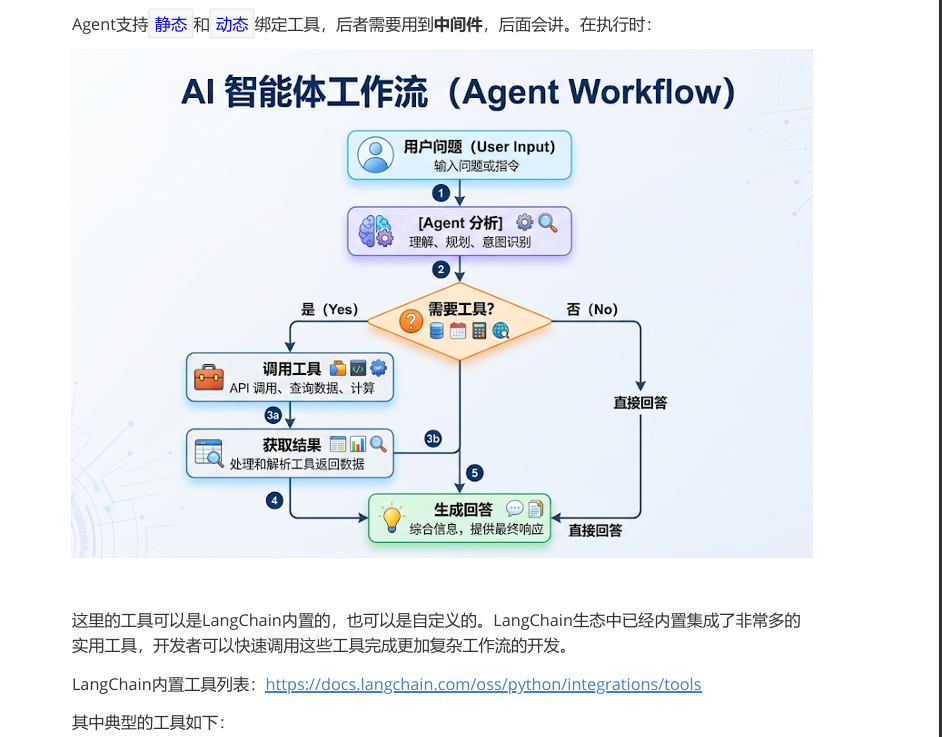
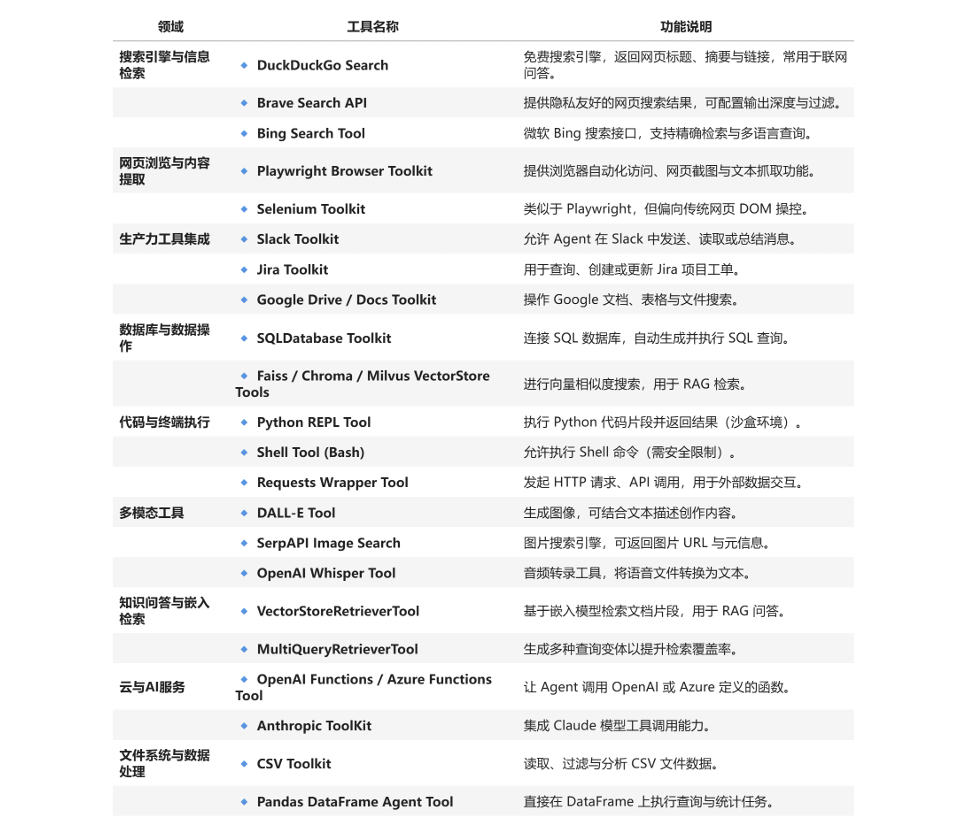

4.1 基本用法
Agents支持绑定一或多个工具。
举例1：绑定一个工具
调用查询天气工具进行天气查询

In [17]:
from langchain.agents import create_agent
from langchain.tools import tool
from rich import print as rprint


@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """
    天气查询工具

    Args:
        city: 城市名称
    """
    return f"{city}的天气为晴朗，25°C。"


agent = create_agent(
    model=model,
    tools=[get_weather]
)
resp = agent.invoke({
    "messages": [
        {"role": "system",
         "content": "你是一个天气查询助手，只回答天气相关的问题，其他问题请直接回答：我不清楚这问题答案。"},
        {"role": "user", "content": "北京的天气怎么样？"}
        # {"role": "user", "content": "100加上50等于多少？"}
    ]
})
rprint(resp)

{
    'messages': [
        SystemMessage(
            content='你是一个天气查询助手，只回答天气相关的问题，其他问题请直接回答：我不清楚这问题答案。',
            additional_kwargs={},
            response_metadata={},
            id='2a5f09e0-11a7-4ee5-bebd-4f605ec58c10'
        ),
        HumanMessage(
            content='北京的天气怎么样？',
            additional_kwargs={},
            response_metadata={},
            id='77bdf68b-84d5-4e46-9cf3-4358a3339cbb'
        ),
        AIMessage(
            content='好的，我来查询一下北京的天气情况。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 53,
                    'prompt_tokens': 305,
                    'total_tokens': 358,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
                    'prompt_cache_hit_tokens': 0,
                    'prompt_cache_miss_tokens': 305
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': '77049919-e7ea-4b16-9ecc-7e07b3cddf87',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f64c7-52d5-7981-a374-01f05c41293f-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '北京'},
                    'id': 'call_00_UssYxZ7LVLeUAkai43Hd4074',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 305,
                'output_tokens': 53,
                'total_tokens': 358,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='北京的天气为晴朗，25°C。',
            name='get_weather',
            id='400bcbf6-6483-4d27-91fd-3501b35f9fda',
            tool_call_id='call_00_UssYxZ7LVLeUAkai43Hd4074'
        ),
        AIMessage(
            content='北京目前的天气是**晴朗**，气温为 
**25°C**，非常舒适宜人的天气！☀️\n\n请问您还需要查询其他城市的天气吗？',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 35,
                    'prompt_tokens': 377,
                    'total_tokens': 412,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256},
                    'prompt_cache_hit_tokens': 256,
                    'prompt_cache_miss_tokens': 121
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': '82068b71-8da1-4958-933a-1adf4cbdf117',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019f64c7-5794-7a20-a82b-3dd9c647304b-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 377,
                'output_tokens': 35,
                'total_tokens': 412,
                'input_token_details': {'cache_read': 256},
                'output_token_details': {}
            }
        )
    ]
}

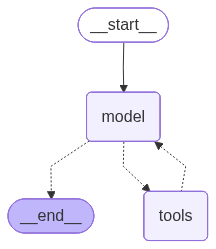

In [20]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

举例2：接入内置工具
绑定内置的TavilySearch搜索工具，可以借助Tavily进行网络搜索和信息爬取。
这里我们需要先在tavily官网注册并获得API-KEY（每月有免费额度）：
https://www.tavily.com/

In [1]:
from langchain_tavily import TavilySearch
from dotenv import load_dotenv
import os

load_dotenv(override=True)
#工具实例化
web_search = TavilySearch(
    tavily_api_key=os.getenv("TAVILY_API_KEY"),
    max_results=2
)
#这是一个高度封装的网络搜索工具，可以直接调用：
web_search.invoke("请问2026年足球世界杯有哪些参赛队？")

{'query': '请问2026年足球世界杯有哪些参赛队？',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'http://www.news.cn/sports/20260401/cd567a6ae1af459ba6a0386a0380cd91/c.html',
   'title': '2026美加墨世界杯48支参赛球队确定',
   'content': '![](//www.news.cn/detail2020/images/ewm.png). ![](//www.news.cn/2021detail/images/qrcode-app.png). [新华网](//www.news.cn/) >  > 正文. # 2026美加墨世界杯48支参赛球队确定. ![](//www.news.cn/2021detail/images/qrcode-app.png). # 2026美加墨世界杯48支参赛球队确定. 2026-04-01 15:06:29  来源：新华网. 新华社北京4月1日电 1日，2026美加墨世界杯预选赛结束全部附加赛比赛。波黑、捷克、土耳其和瑞典队通过欧洲区预选赛附加赛晋级，刚果（金）和伊拉克队通过洲际附加赛晋级。四届世界杯冠军得主意大利队连续三届无缘世界杯。. A组：墨西哥、南非、韩国、捷克. B组：加拿大、波黑、卡塔尔、瑞士. C组：巴西、摩洛哥、海地、苏格兰. D组：美国、巴拉圭、澳大利亚、土耳其. E组：德国、库拉索、科特迪瓦、厄瓜多尔. F组：荷兰、日本、瑞典、突尼斯. G组：比利时、埃及、伊朗、新西兰. H组：西班牙、佛得角、沙特阿拉伯、乌拉圭. I组：法国、塞内加尔、伊拉克、挪威. J组：阿根廷、阿尔及利亚、奥地利、约旦. K组：葡萄牙、刚果（金）、乌兹别克斯坦、哥伦比亚. L组：英格兰、克罗地亚、加纳、巴拿马. [【纠错】](javascript:void(0);)  【责任编辑:焦鹏】. [深度观察](http://www.news.cn/depthobserve/index.html). * [![](../../20260607/ea0202ecdcad46158a2eb6f6fbcfe7ce/977f2

可以直接带入create_agent中作为外部工具。

In [5]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langchain_tavily import TavilySearch
from dotenv import load_dotenv
import os

load_dotenv(override=True)
from rich import print as rprint

# 2.工具实例化
web_search = TavilySearch(max_results=2)

# 3.创建Agent
agent = create_agent(
    model=model,
    tools=[web_search],
    #system_prompt="你是一名多才多艺的智能助手，可以调用工具帮助用户解决问题。"
)
# 4.运行Agent获得结果
result = agent.invoke(
    {"messages": [{"role": "user", "content": "请帮我查询2024年诺贝尔物理学奖得主是谁？"}]}
)
rprint(result)
# print(result['messages'][-1].content)

{
    'messages': [
        HumanMessage(
            content='请帮我查询2024年诺贝尔物理学奖得主是谁？',
            additional_kwargs={},
            response_metadata={},
            id='46452c08-a520-4611-b81b-54f4ba47a0fc'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 86,
                    'prompt_tokens': 1822,
                    'total_tokens': 1908,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 1792},
                    'prompt_cache_hit_tokens': 1792,
                    'prompt_cache_miss_tokens': 30
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': '2596db09-c3a5-4140-9bee-7e7fbc9c0750',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f64d8-3c9f-72a0-b7d0-1ee3b83b141e-0',
            tool_calls=[
                {
                    'name': 'tavily_search',
                    'args': {
                        'query': '2024年诺贝尔物理学奖得主',
                        'search_depth': 'advanced',
                        'time_range': 'year'
                    },
                    'id': 'call_00_YPAiwM1kmCg9ALuRyFF61121',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 1822,
                'output_tokens': 86,
                'total_tokens': 1908,
                'input_token_details': {'cache_read': 1792},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='{"query": "2024年诺贝尔物理学奖得主", "follow_up_questions": null, "answer": null, "images": 
[], "results": [{"url": 
"https://wuu.wikipedia.org/wiki/%E8%AF%BA%E8%B4%9D%E5%B0%94%E7%89%A9%E7%90%86%E5%AD%A6%E5%A5%96", "title": 
"诺贝尔物理学奖 - 吴语维基百科", "content": "维基百科\\n\\n# 
诺贝尔物理学奖\\n\\n诺贝尔物理学奖（瑞典语：Nobelpriset i 
fysik）是瑞典皇家科学院为表彰拉物理学作出最杰出个贡献，自1901年起一年一度颁发个奖项；奖金由诺贝尔基金会发出。奖项勒
阿尔弗雷德·诺贝尔1895年个遗嘱中设立个五个诺贝尔奖之一，另外四个分别为化学奖、文学奖、和平奖搭生理学或医学奖。诺贝尔
物理学奖被普遍认为是拉物理学领域能够取得个最高荣誉。\\n颁奖典礼拉每年12月10号，即诺贝尔逝世周年纪念日，勒瑞典斯德哥
尔摩举行。首届诺贝尔物理学奖由发现X射线个德国荷兰物理学家威廉·伦琴获得。截至2016年，共有203人得奖，其中女性得主仅有
两位：1903年个玛丽·居里搭1963年个玛丽亚·格佩特-梅耶。\\n\\nWikimedia Foundation\\nPowered by MediaWiki", "score": 
0.26535112, "raw_content": null}, {"url": 
"https://kannewyork.com/tag/%E8%AF%BA%E8%B4%9D%E5%B0%94%E7%89%A9%E7%90%86%E5%AD%A6%E5%A5%96", "title": 
"诺贝尔物理学奖", "content": "### 诺贝尔物理学奖\\n\\n#### 普林斯顿大学两学者与三校友获诺贝尔奖\\n\\n#### 
张首晟讣告发出后张家人称不知其患有抑郁症\\n\\n#### 沃夫．梅辛的传奇\\n\\n#### 无形纳米防弹衣\\n\\n#### 
首次观测到中子星碰撞产生重力波和黄金\\n\\n#### 美科学家因引力波研究获诺贝尔物理学奖\\n\\n#### 
万物共有主宰，情绪影响世界\\n\\n#### 真英雄 他发现惊天秘密抗工业巨头救无数人(图)\\n\\n#### 六位现当代著名科学家 
他们为什么信神?\\n\\n#### 2016诺贝尔物理学奖:3英裔美国科学家分享\\n\\n#### 2016年诺贝尔物理奖揭晓！\\n\\n#### 
量子力学惊人证明：万物皆有灵！\\n\\n#### 为甚么大科学家信神\\n\\n#### 宇宙膨胀速度超预期颠覆甚么观念？\\n\\n#### 
研究：宇宙膨胀比预期快 最终或撕毁自己\\n\\n#### 全球最聪明的10个人 爱因斯坦排第9第一是...(组图)\\n\\n#### 
重力波有实用价值？六种疑问耐人寻味\\n\\n#### 诺贝尔物理学奖获得者：暗能量足以推动宇宙\\n\\n#### 
假如一千年前有诺贝尔奖，谁会得奖呢？\\n\\n#### 信神的大科学家知多少？\\n\\n#### 
看看常春藤顶尖名校普林斯顿大学（要求，学费，华人的比例篇）\\n\\n#### 诺贝尔化学 物理学 生理学 及医学奖揭晓", 
"score": 0.2253829, "raw_content": null}], "response_time": 7.79, "request_id": 
"dacbb5d7-8c55-4f71-8a00-7d8d29a5d6c7"}',
            name='tavily_search',
            id='45214306-95f9-432c-a97e-20c41e1759c1',
            tool_call_id='call_00_YPAiwM1kmCg9ALuRyFF61121'
        ),
        AIMessage(
            content='搜索结果没有直接显示详细信息，让我再搜索一下。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 95,
                    'prompt_tokens': 2729,
                    'total_token

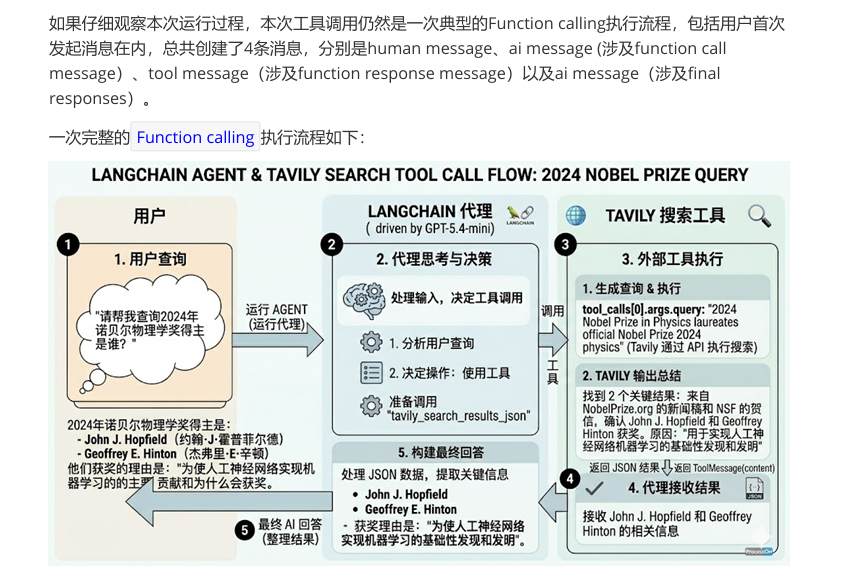

举例3：绑定多个工具

In [6]:
from langchain.agents import create_agent
from langchain.tools import tool
from dotenv import load_dotenv
from rich import print as rprint

load_dotenv()


@tool(parse_docstring=True)
def get_weather(city: str):
    """
    天气查询工具

    Args:
        city: 城市名称
    """
    return f"{city}今天天气挺好"


@tool(parse_docstring=True)
def get_news():
    """
    新闻查询工具
    """
    return "近期，受全球储蓄芯片短缺等多重因素影响，多地回收商称废旧手机回收市场迎来“火热潮”，回收价格普遍上涨，旧手机成“香饽饽”。"


agent = create_agent(
    model,
    tools=[get_weather, get_news]
)
response = agent.invoke({
    "messages": ["你好，杭州今天的天气如何？今天有哪些新闻？"]
})
rprint(response)

{
    'messages': [
        HumanMessage(
            content='你好，杭州今天的天气如何？今天有哪些新闻？',
            additional_kwargs={},
            response_metadata={},
            id='d132e077-01d4-441a-968b-8151e7bafd14'
        ),
        AIMessage(
            content='好的，我来帮你查询杭州的天气和今天的新闻！',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 71,
                    'prompt_tokens': 318,
                    'total_tokens': 389,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
                    'prompt_cache_hit_tokens': 0,
                    'prompt_cache_miss_tokens': 318
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': 'ea628cc0-cf34-47b0-94a4-6fcc59e49e5e',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f64dc-bab7-7823-af97-974b22432024-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '杭州'},
                    'id': 'call_00_XpG8nvfSPKNPVZ3ORS9z8965',
                    'type': 'tool_call'
                },
                {'name': 'get_news', 'args': {}, 'id': 'call_01_lzCBeWY4AwHIE2srPU0Q3438', 'type': 'tool_call'}
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 318,
                'output_tokens': 71,
                'total_tokens': 389,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='杭州今天天气挺好',
            name='get_weather',
            id='a6c33cbd-2c60-4e9c-b13d-42a9510c00d6',
            tool_call_id='call_00_XpG8nvfSPKNPVZ3ORS9z8965'
        ),
        ToolMessage(
            content='近期，受全球储蓄芯片短缺等多重因素影响，多地回收商称废旧手机回收市场迎来“火热潮”，回收价格普遍
上涨，旧手机成“香饽饽”。',
            name='get_news',
            id='32502aaa-106d-4328-afe3-1cc50dca71f9',
            tool_call_id='call_01_lzCBeWY4AwHIE2srPU0Q3438'
        ),
        AIMessage(
            content='以下是查询结果：\n\n### 🌤️ 杭州今日天气\n杭州今天天气**挺好**，适合出门活动哦！\n\n### 📰 
今日新闻\n近期，受全球储蓄芯片短缺等多重因素影响，多地回收商称**废旧手机回收市场**迎来"火热潮"，回收价格普遍上涨，
旧手机变成"香饽饽"啦！\n\n如果你还有其他问题，欢迎继续问我～',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 84,
                    'prompt_tokens': 452,
                    'total_tokens': 536,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256},
                    'prompt_cache_hit_tokens': 256,
                    'prompt_cache_miss_tokens': 196
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': 'c3d8a960-a09f-4c84-8a00-a2857434adba',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019f64dc-bfc7-78f3-b9ab-e1fb53e17e8e-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 452,
                'output_tokens': 84,
                'total_tokens': 536,
                'input_token_details': {'cache_read': 256},
                'output_token_details': {}
            }
        )
    ]
}

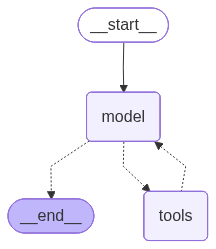

In [8]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

注意：只给 Agent 需要的工具，工具太多会混淆。一般2-5 个工具最佳

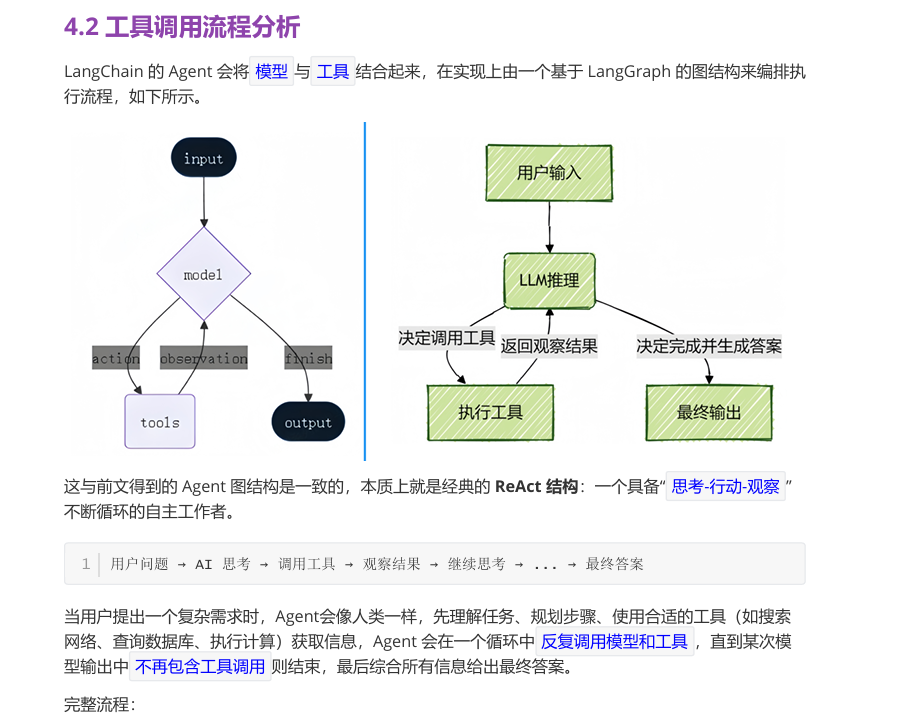

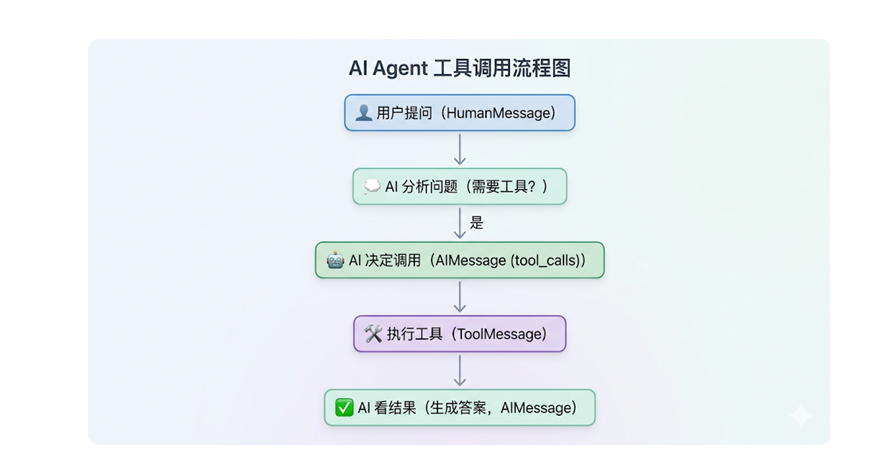
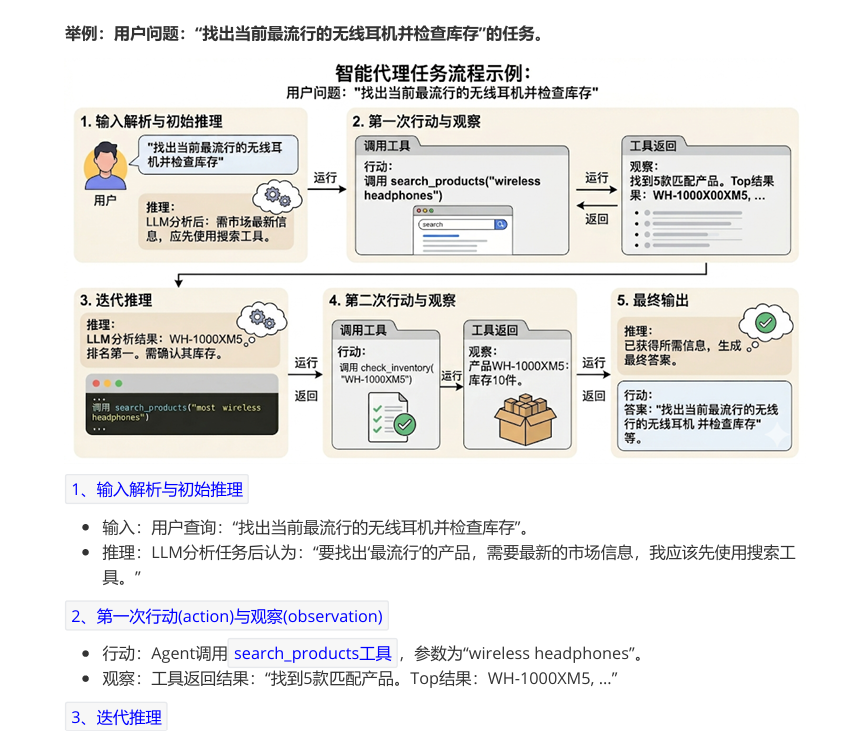

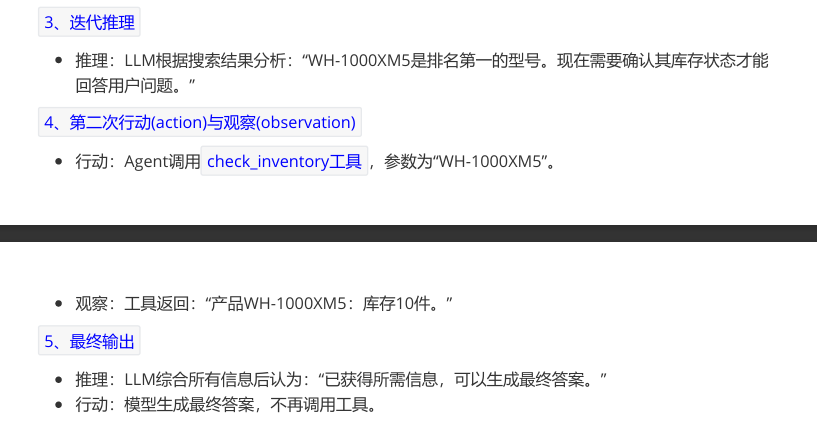

4.3 重试机制
Agent可以在工具调用结果不满足要求时，自主重试。

In [9]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv
from rich import print as rprint

load_dotenv(override=True)
flag = 0


@tool
def get_weather(city: str):
    """
    天气查询工具

    Args:
    city: 城市名称
    """
    global flag
    flag += 1
    if flag < 2:
        # raise Exception("暂时无法访问")
        return "TEMP_UNAVAILABLE: 天气服务暂时不可用，请稍后重试"
    return f"{city}今天天气挺好"


messages = [
    SystemMessage("""
        你是一个天气助手。
        当工具返回以 'TEMP_UNAVAILABLE:' 开头的结果时，
        说明是临时故障，不要立即放弃；
        你应再次调用同一个工具，最多重试 2 次。
        如果 2 次后仍失败，再向用户说明服务暂时不可用。
        """),
    HumanMessage("你好，杭州今天的天气如何？")
]
agent = create_agent(model, tools=[get_weather])
response = agent.invoke({"messages": messages})
# rprint(response)
for msg in response["messages"]:
    msg.pretty_print()


================================ System Message ================================


        你是一个天气助手。
        当工具返回以 'TEMP_UNAVAILABLE:' 开头的结果时，
        说明是临时故障，不要立即放弃；
        你应再次调用同一个工具，最多重试 2 次。
        如果 3 次后仍失败，再向用户说明服务暂时不可用。
        
================================ Human Message =================================

你好，杭州今天的天气如何？
================================== Ai Message ==================================

让我帮你查询一下杭州今天的天气情况。
Tool Calls:
  get_weather (call_00_Uy1dIPGE7RiVqlpvzODH3815)
 Call ID: call_00_Uy1dIPGE7RiVqlpvzODH3815
  Args:
    city: 杭州
================================= Tool Message =================================
Name: get_weather

TEMP_UNAVAILABLE: 天气服务暂时不可用，请稍后重试
================================== Ai Message ==================================

看起来暂时遇到了点小故障，我再试一次。
Tool Calls:
  get_weather (call_00_yYombel8dqqUFcNi5HBg6465)
 Call ID: call_00_yYombel8dqqUFcNi5HBg6465
  Args:
    city: 杭州
================================= Tool Message =============================

模型2次调用get_weather，最终获得了满意的结果。

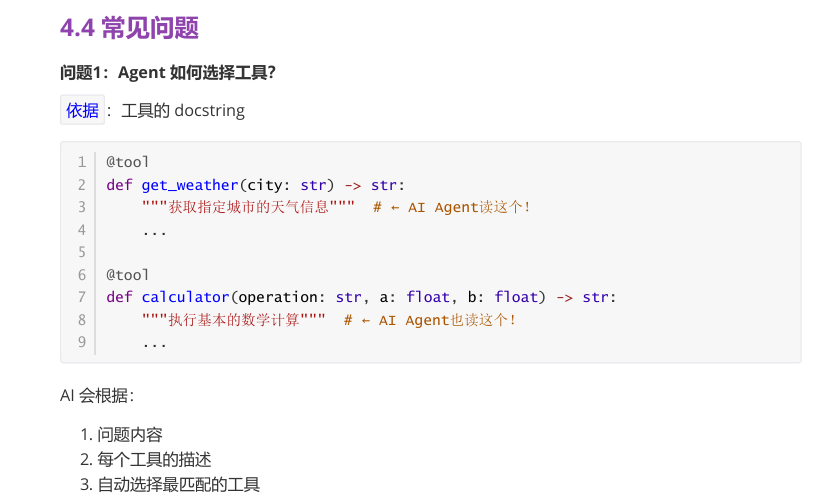
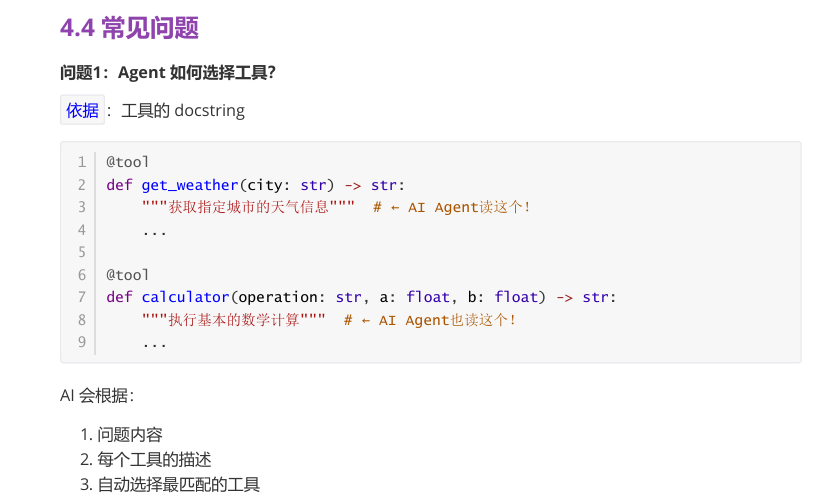
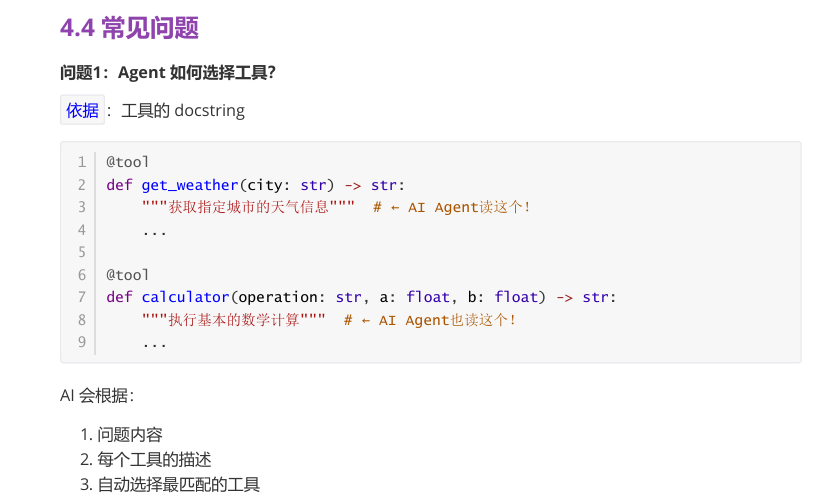

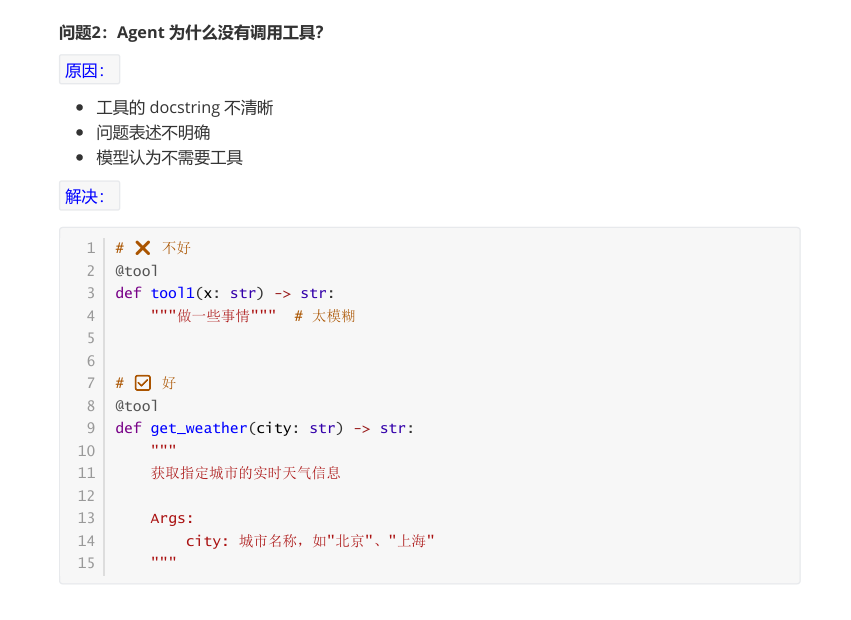

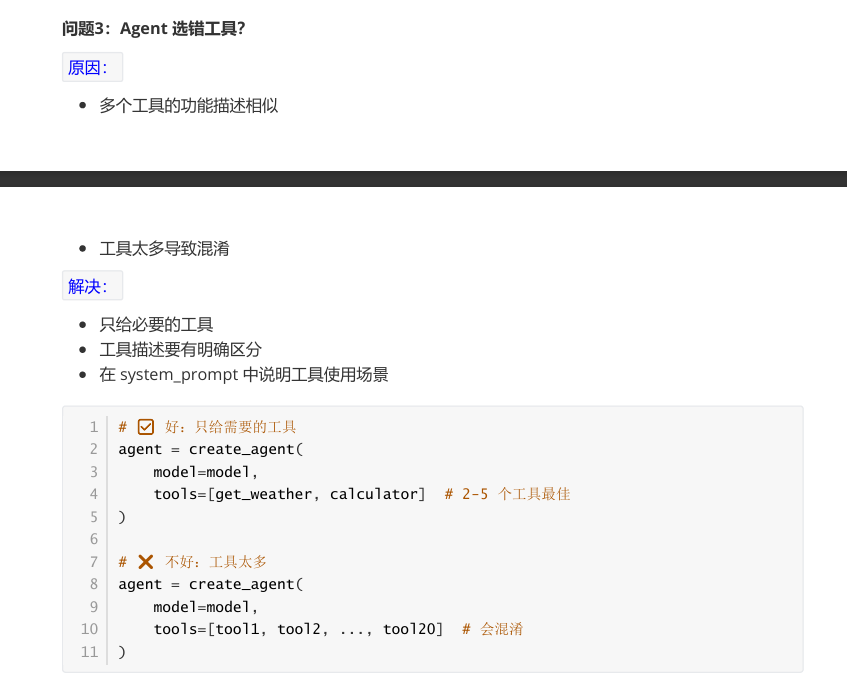

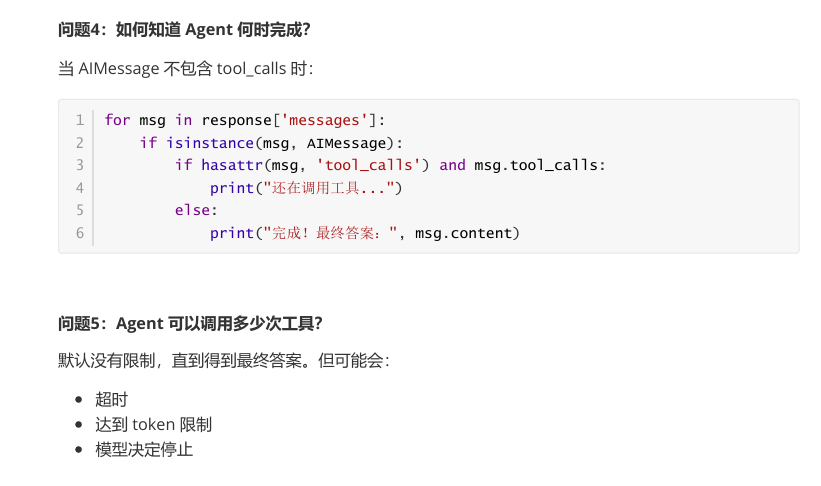

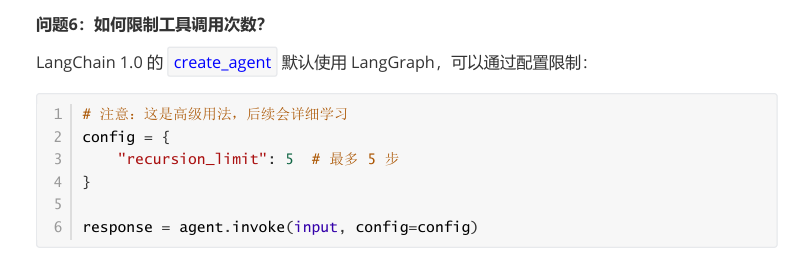